# Outliers:

- Outliers are data points that significantly differ from other observations in a dataset, potentially skewing results and affecting model performance.
- Treatment methods include removing outliers, replacing them with central tendencies (like the median) or derived limits, applying data transformations, using robust estimation techniques such as M-estimation, or employing specialized algorithms to reduce their influence.
- The best method depends on the nature of the data, the cause of the outlier, and whether the outlier provides valuable insights or is a data error.


#### Methods for Identifying Outliers:
Before treating them, outliers must be identified. Common methods include: 
- Data Visualization: Using techniques like box plots to visualize data distribution and identify points outside the typical range. 
- Statistical Tests: Employing statistical tests such as Z-scores, which flag data points falling a certain number of standard deviations from the mean. 
- Interquartile Range (IQR) Method: A statistical approach that identifies outliers as data points falling below Q1 - 1.5IQR or above Q3 + 1.5IQR.

#### Treatment Methods:
Once identified, outliers can be handled in several ways: 

1) Removal/Trimming:
- Removal: Delete the outlier data point or row from the dataset. This is suitable for a small number of outliers but can be impractical with many. 

- Trimming: A less extreme version of removal where the outliers are excluded based on a threshold, often by removing values below a certain percentile or above another. 

2) Replacement/Imputation:
- Winsorisation: Capping the extreme values at a certain percentile or limit, effectively replacing the outlier with a value closer to the bulk of the data. 

- Imputation: Replacing outliers with a more representative value from the dataset, such as the median, which is less affected by extreme values. 

3) Transformation:
- Data Transformation: Apply mathematical transformations (like logarithmic or square root) to the data, which can reduce the skewness of the data and lessen the influence of outliers without removing them. 

4) Robust Methods:
- Robust Estimation Techniques: Using statistical methods that are less sensitive to outliers. Instead of using the mean, which is heavily influenced by outliers, methods like using the median can provide more reliable results. 
Algorithmic Treatment:

5) Outlier-Specific Algorithms:
- Employ algorithms designed to identify and treat outliers as part of the preprocessing pipeline for machine learning models.

#### Factors to Consider
- Nature of the Outlier: Determine if the outlier is a genuine data point (e.g., a natural variation) or a data error. 
- Dataset Size and Distribution: Larger datasets can handle outliers better, and the overall data distribution influences the most effective treatment. 
- Analysis Goals: Decide if the outlier provides important information or if its presence will distort the analysis and should be handled.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('raw_sales2.csv')

In [3]:
df.head()

,datesold,postcode,price,propertyType,bedrooms
0,2007-02-07 00:00:00,2607,525000,house,4
1,2007-02-27 00:00:00,2906,290000,house,3
2,2007-03-07 00:00:00,2905,328000,house,3
3,2007-03-09 00:00:00,2905,380000,house,4
4,2007-03-21 00:00:00,2906,310000,house,3


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29580 entries, 0 to 29579
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   datesold      29580 non-null  object
 1   postcode      29580 non-null  int64 
 2   price         29580 non-null  int64 
 3   propertyType  29580 non-null  object
 4   bedrooms      29580 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 1.1+ MB


In [5]:
df.describe()

,postcode,price,bedrooms
count,29580.000000,2.958000e+04,29580.000000
mean,2730.249730,6.097363e+05,3.250169
std,146.717292,2.817079e+05,0.951275
min,2600.000000,5.650000e+04,0.000000
25%,2607.000000,4.400000e+05,3.000000
50%,2615.000000,5.500000e+05,3.000000
75%,2905.000000,7.050000e+05,4.000000
max,2914.000000,8.000000e+06,5.000000


### Outlier Detection:

##### 1) Using BoxPlot:

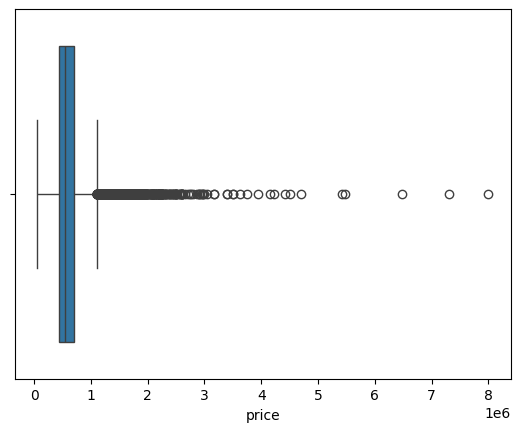

In [6]:
sns.boxplot(data= df, x= 'price')
plt.show()

##### 2) Using Z-Score:

For Normally Distributed Data, 0.03% Data Lies Beyond 3 Standard Deviations from Mean.

In [7]:
def find_outliers(data):
    """
    Function to find Data Points that lies beyond 3 Standard Deviations from Mean of Data.
    """

    outliers = []
    
    mean = np.mean(data)
    std = np.std(data)

    lower_limit = mean - 3*std
    upper_limit = mean + 3*std

    for data_point in data:
        if data_point < lower_limit or data_point > upper_limit:
            outliers.append(data_point)

    return outliers

In [10]:
outliers = find_outliers(df['price'])
print(outliers)

[1530000, 1780000, 1460000, 3500000, 2100000, 1580000, 2600000, 1875000, 2200000, 1620000, 1562500, 2350000, 1580000, 7300000, 1670000, 1780000, 2400000, 1530000, 1567140, 1700000, 1675000, 2060000, 1750000, 1500000, 1725000, 1455000, 2000000, 1475000, 4150000, 1780000, 1650000, 2500000, 5425000, 2200000, 2375000, 2100000, 1950000, 1980000, 1525000, 1900000, 1460000, 1500000, 1500000, 2760000, 1550000, 1605000, 1730000, 1650000, 1575000, 1530000, 1510000, 1501000, 1880000, 1620000, 1650000, 1470000, 1495000, 1600000, 1910000, 1485000, 1965000, 1640000, 1777500, 1500000, 1480000, 1650000, 1625000, 1540000, 2600000, 1900000, 3160000, 1975000, 1555000, 1900000, 1785000, 1701000, 1510000, 2080000, 3400000, 2050000, 1510000, 2550000, 1900000, 1801000, 1950000, 3400000, 1650000, 1915000, 1870000, 1560000, 2400000, 2090000, 1490000, 1670000, 1550000, 1560000, 1700000, 1800000, 1900000, 1710000, 1475000, 2125000, 1600000, 1675000, 1952500, 1670000, 1665000, 2150000, 1460000, 1715000, 1750000, 

In [11]:
len(outliers)

461

In [12]:
# Percentage of Data Points Outside 3 Standard Deviations from Mean:

len(outlires) / len(df) * 100

1.5584854631507776

##### 3) Using IQR (Inter Quartile Range):

In [14]:
# Finding First and Third Quartiles from Data:

q1 = np.quantile(a= df['price'], q= 0.25)
q3 = np.quantile(a= df['price'], q= 0.75)

print(q1, q3)

440000.0 705000.0


In [15]:
iqr = q3 - q1
print(iqr)

265000.0


In [16]:
def find_outliers(data):
    """
    Finding Outliers Based on Inter Quartile Range.
    """

    outliers = []
    
    q1 = np.quantile(a= data, q= 0.25)
    q3 = np.quantile(a= data, q= 0.75)

    iqr = q3 - q1

    for data_point in data:
        if data_point < (q1 - 1.5*iqr) or data_point > (q3 + 1.5*iqr):
            outliers.append(data_point)

    return outliers

In [17]:
outliers = find_outliers(df['price'])
print(outliers)

[1530000, 1780000, 1460000, 1105000, 1180000, 1165000, 1300000, 1380000, 1150000, 1120000, 1425000, 1250000, 1375000, 3500000, 1150000, 2100000, 1580000, 2600000, 1310000, 1875000, 2200000, 1280000, 1110000, 1200000, 1620000, 1562500, 1210000, 1430000, 1365000, 1340000, 1420000, 1350000, 2350000, 1417500, 1580000, 1305000, 1110000, 7300000, 1670000, 1352000, 1780000, 2400000, 1170000, 1310000, 1200000, 1126000, 1187000, 1530000, 1175000, 1567140, 1130000, 1700000, 1151500, 1105000, 1240000, 1675000, 1255000, 2060000, 1220000, 1150000, 1140000, 1350001, 1750000, 1310000, 1500000, 1135001, 1200000, 1725000, 1455000, 1150000, 1110000, 1330000, 2000000, 1330000, 1475000, 1350000, 4150000, 1300000, 1780000, 1200000, 1650000, 1175000, 2500000, 5425000, 1200000, 1250000, 2200000, 2375000, 1270000, 1350000, 1261000, 2100000, 1175000, 1200000, 1200000, 1270000, 1221000, 1327000, 1950000, 1150000, 1260000, 1300000, 1980000, 1110000, 1380000, 1525000, 1295000, 1900000, 1150000, 1163000, 1350000, 

In [18]:
len(outliers)

1374

In [20]:
# Percentage of Outliers:
len(outliers) / len(df) * 100

4.645030425963489

### Outlier Treatment:

##### 1) Data Transformation:

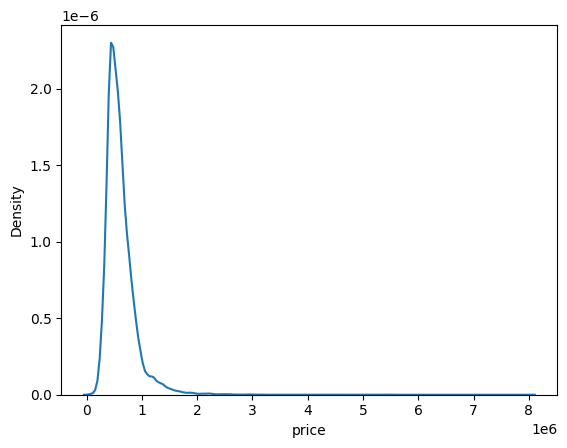

In [21]:
sns.kdeplot(data= df, x= 'price')
plt.show()

In [22]:
# Log Transformation:

df['price_log_transformed'] = np.log(df['price'])

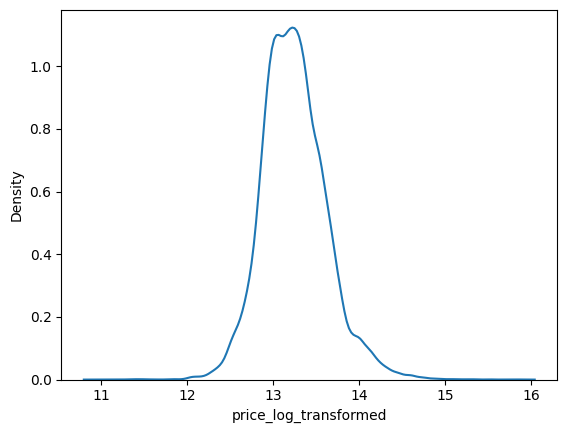

In [23]:
sns.kdeplot(data= df, x= 'price_log_transformed')
plt.show()

In [24]:
# Square Root Transformation:

df['price_sqrt_transformed'] = np.sqrt(df['price'])

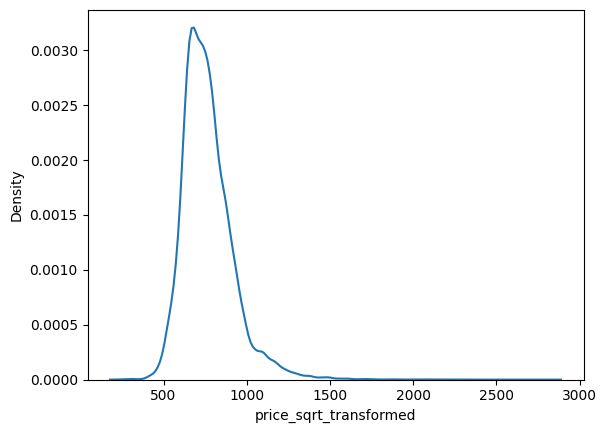

In [25]:
sns.kdeplot(data= df, x= 'price_sqrt_transformed')
plt.show()